# Home Credit Default Risk — Modeling

This notebook builds on the processed dataset from the feature engineering notebook (02_feature_engineering). It trains and compares models that predict whether an applicant will have payment difficulties (`TARGET`), starting with an interpretable baseline (Logistic Regression) and moving on to gradient boosting models (LightGBM, XGBoost). Beyond the AUC-ROC score, it also looks at what the results mean in business terms and checks the final model for fairness.

## Key Findings

* Setup: modeled `TARGET` (8.07% defaults) on the processed dataset from notebook 02 (307,511 applicants, 242 features after removing `TARGET` and `SK_ID_CURR`), using a stratified 80/20 train/validation split; the metric is AUC-ROC because accuracy is meaningless with such a strong class imbalance.
* Baseline: a Logistic Regression on standardized features (scaler fitted on the training data only) reaches a validation AUC of 0.7606, with no sign of overfitting (train 0.7595).
* Gradient boosting: LightGBM reaches 0.7773 (train 0.8304), XGBoost 0.7745 and the tuned LightGBM 0.7796. The three boosting models perform practically the same, clearly above the baseline but with a moderate overfitting gap of 0.05 to 0.07.
* Tuning: a randomized search (20 parameter combinations, 3-fold cross-validation on the training data only) improved the validation AUC by just 0.0023, a difference within normal random variation; the first LightGBM with default settings is already close to what this feature set allows.
* Decisions instead of scores: at the standard threshold of 0.5, the tuned LightGBM flags 28.9% of the applicants, finds 67.8% of the defaults and 19.0% of the flagged applicants actually defaulted; between thresholds of 0.3 and 0.8, the flagged share ranges from 57% to 4%. The best threshold depends on the cost of a missed default relative to a rejected good applicant, which the dataset does not contain.
* Feature importance: the three external scores (`EXT_SOURCE_1/2/3`) carry about a third of the model's gain; seven of the top 15 features come from the linked tables, four of them from the ratio features engineered in notebook 02.
* Fairness check: male applicants are flagged more often than female applicants (38.4% vs. 23.9%), partly reflecting a higher actual default rate (10.2% vs. 7.0%), but good male applicants are also wrongly flagged more often (false positive rate 34.2% vs. 21.1%); the dataset records only two gender values, so no other groups can be assessed.
* Known limitation: preprocessing statistics from notebook 02 (imputation medians, income cap, one-hot categories) were computed on the full training data before the split, so a small amount of validation information may leak into preprocessing (see the Limitations section and the Conclusion).

Let's first import the libraries and set up the same plot style as in the EDA and feature engineering notebooks, for consistency.

In [1]:
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', 200)

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.figsize'] = (7, 4)

Let's load the processed dataset exported at the end of the feature engineering notebook. Because it was saved as Parquet, the data types (e.g. the boolean columns from one-hot encoding) should come back exactly as they were, without any re-casting.

In [2]:
df = pd.read_parquet('/kaggle/input/notebooks/niklaskitschen/02-feature-engineering/app_train_processed.parquet')

print('Shape:', df.shape)

Shape: (307511, 244)


Confirmed: the shape (307,511 rows, 244 columns) matches exactly what the feature engineering notebook exported, so nothing was lost between the two notebooks.

quick check:

In [3]:
print('Total missing values:', df.isnull().sum().sum())
print()
print(df.dtypes.value_counts())

Total missing values: 0

bool       142
float64     62
int64       40
Name: count, dtype: int64


Confirmed: no missing values, and the dtype counts add up to 244 columns (142 bool + 62 float64 + 40 int64). The boolean columns from one-hot encoding and the flag columns survived the Parquet round trip as `bool`, so the dataset is ready for modeling as it is.

Before splitting the data, let's look at the target distribution once more. The EDA showed a strong class imbalance, and it directly determines how we split the data, which metric we can trust, and how the models need to be configured.

In [4]:
target_counts = df['TARGET'].value_counts()
target_share = df['TARGET'].value_counts(normalize=True)

print(pd.concat([target_counts, target_share.round(4)], axis=1, keys=['count', 'share']))

         count   share
TARGET                
0       282686  0.9193
1        24825  0.0807


Confirmed: only 8.07% of the loans (24,825 of 307,511) are defaults, matching the imbalance found in the EDA. This has three consequences for our modeling approach:

- **Accuracy is meaningless here.** A model that always predicts "no default" would reach 91.9% accuracy while catching zero defaults. We evaluate with AUC-ROC instead, which measures how well the model ranks risky applicants above safe ones, independent of a fixed threshold.
- **The split must be stratified.** A purely random split could shift the default share between training and validation data by chance. Stratifying on `TARGET` keeps the 8.07% in both parts, so validation results stay comparable.
- **The models need to account for the imbalance.** Later we use class weighting so that the rare default class isn't drowned out during training.

### Why we split the training data ourselves

Home Credit also provides a separate test file (`application_test.csv`), but it comes without the `TARGET` column — the true outcomes are withheld for the Kaggle leaderboard. We can't measure our own model's performance on data where we don't know the correct answer.

So we hold out part of the labeled training data as a validation set. The model never sees it during training, which lets us check how well it performs on unseen applicants, detect overfitting, and compare models fairly. This also keeps the project self-contained: the reported scores come from our own evaluation, independent of any leaderboard submission. Using the test file would additionally require repeating all the feature engineering steps from notebook 02 on it.

Next, we separate the features from the target and create the validation split. `SK_ID_CURR` is only an identifier without predictive meaning, so we exclude it from the features. We hold out 20% of the data for validation.

In [5]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print('Default share train:', round(y_train.mean(), 4))
print('Default share val:  ', round(y_val.mean(), 4))

X_train: (246008, 242) | X_val: (61503, 242)
Default share train: 0.0807
Default share val:   0.0807


Confirmed: the split worked as intended. Training and validation sets contain 246,008 and 61,503 rows (80/20, summing to the original 307,511), and both keep the same default share of 8.07% thanks to stratification. Each has 242 feature columns — the 244 columns of the processed dataset minus `TARGET` and `SK_ID_CURR`.

From here on, the validation set stays untouched until we evaluate a model: all fitting steps in this notebook, including scaling, are learned on the training data only and then merely applied to the validation data. Otherwise information from the validation set would leak into the training process (data leakage), and the validation score would look better than the model's real performance on new applicants.

### Limitations

- **Minor preprocessing leakage.** Imputation medians, the 99th-percentile cap on `AMT_INCOME_TOTAL`, and the category set for one-hot encoding were determined on the full training data in the feature engineering notebook, i.e. before the train/validation split. Strictly speaking, this lets a small amount of validation-set information into preprocessing. `TARGET` itself was never used to compute any transformation, and with over 300,000 rows and robust statistics like the median, the effect is expected to be negligible. A production pipeline would fit these steps on the training portion only (e.g. inside a scikit-learn `Pipeline`).

## Baseline: Logistic Regression

We start with a simple, interpretable baseline. It gives us a reference score that any more complex model has to beat to justify its added complexity.

### Scaling the features

Logistic Regression is sensitive to feature scales: `AMT_INCOME_TOTAL` is in the hundreds of thousands, while ratio features like `CC_UTILIZATION_RATIO` are around 0-1. Without scaling, the optimizer converges slowly and the regularization penalizes features unevenly. We standardize the numeric columns (mean 0, standard deviation 1) with a `StandardScaler`. Alternatives like min-max scaling or a `RobustScaler` exist; standardization is the common default for Logistic Regression, and heavy outliers were already limited by the capping in notebook 02.

Two details matter here:

- **We fit the scaler on the training data only** and merely apply it to the validation data, as discussed above. Otherwise the validation set's mean and standard deviation would leak into the training process.
- **We leave the boolean columns (0/1) unscaled.** They are already on a comparable scale, and keeping them as 0/1 keeps their coefficients easy to interpret. We only convert them to integers so the model receives a purely numeric matrix.

Tree-based models like LightGBM don't need scaling, so we keep the original `X_train` and `X_val` for them and use the scaled copies only for Logistic Regression.

In [6]:
bool_cols = X_train.select_dtypes('bool').columns.tolist()
num_cols = X_train.select_dtypes(exclude='bool').columns.tolist()
print('Boolean columns:', len(bool_cols), '| Numeric columns to scale:', len(num_cols))

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

scaler = StandardScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])

X_train_scaled[bool_cols] = X_train_scaled[bool_cols].astype(int)
X_val_scaled[bool_cols] = X_val_scaled[bool_cols].astype(int)

print('Train mean (should be ~0):', round(X_train_scaled[num_cols].mean().abs().max(), 6))
print('Train std  (should be ~1):', X_train_scaled[num_cols].std().round(3).unique())

Boolean columns: 142 | Numeric columns to scale: 100
Train mean (should be ~0): 0.0
Train std  (should be ~1): [1.]


Confirmed: 142 boolean and 100 numeric columns, together the 242 feature columns. On the training data, all 100 scaled columns now have a mean of 0 and a standard deviation of 1, so the scaling worked. The boolean columns stay as 0/1 integers.

quick check: the validation data was scaled using the mean and standard deviation of the training data. Because the validation applicants are different people, their scaled values should be close to, but not exactly, 0 and 1. Small deviations confirm that the training statistics were applied; exact values of 0 and 1 would mean the scaler had been fitted on the validation data as well.

In [7]:
val_std = X_val_scaled[num_cols].std()

print('Val mean, largest deviation from 0:', round(X_val_scaled[num_cols].mean().abs().max(), 4))
print('Val std, range:', round(val_std.min(), 3), 'to', round(val_std.max(), 3))

Val mean, largest deviation from 0: 0.013
Val std, range: 0.0 to 2.079


The mean check looks as expected: the largest deviation from 0 is only 0.013, so the training statistics were applied correctly. The standard deviations, however, range from 0.0 to 2.079 — wider than the values close to 1 we expected. Before moving on, let's find out which columns cause this, to make sure it's not a mistake in our scaling.

In [8]:
outliers = val_std[(val_std < 0.5) | (val_std > 1.5)].sort_values()

print(outliers.round(3))
print()
print(X_train[outliers.index].nunique())

print('Columns within 0.5-1.5:', ((val_std >= 0.5) & (val_std <= 1.5)).sum(), 'of', len(val_std))

FLAG_MOBIL                         0.000
BUREAU_CREDIT_SUM_OVERDUE_TOTAL    0.361
FLAG_DOCUMENT_10                   1.732
FLAG_DOCUMENT_12                   2.000
AMT_REQ_CREDIT_BUREAU_QRT          2.079
dtype: float64

FLAG_MOBIL                            2
BUREAU_CREDIT_SUM_OVERDUE_TOTAL    1026
FLAG_DOCUMENT_10                      2
FLAG_DOCUMENT_12                      2
AMT_REQ_CREDIT_BUREAU_QRT            10
dtype: int64
Columns within 0.5-1.5: 95 of 100


Only five of the 100 numeric columns are affected. Three of them (`FLAG_MOBIL`, `FLAG_DOCUMENT_10`, `FLAG_DOCUMENT_12`) have just two distinct values, and the other two are count/amount columns with extreme values. Our hypothesis: the flags are so rare that small differences between the training and validation set shift their standard deviation, and the two other columns have outliers that fall into only one of the two sets.

To check this, we compare the maximum and the number of non-zero values in both sets for these five columns.

In [9]:
check_cols = ['FLAG_MOBIL', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12',
              'AMT_REQ_CREDIT_BUREAU_QRT', 'BUREAU_CREDIT_SUM_OVERDUE_TOTAL']

summary = pd.DataFrame({
    'train_max': X_train[check_cols].max(),
    'val_max': X_val[check_cols].max(),
    'train_nonzero': (X_train[check_cols] != 0).sum(),
    'val_nonzero': (X_val[check_cols] != 0).sum(),
})
print(summary)

                                 train_max    val_max  train_nonzero  \
FLAG_MOBIL                             1.0        1.0         246007   
FLAG_DOCUMENT_10                       1.0        1.0              4   
FLAG_DOCUMENT_12                       1.0        1.0              1   
AMT_REQ_CREDIT_BUREAU_QRT             19.0      261.0          40400   
BUREAU_CREDIT_SUM_OVERDUE_TOTAL  3756681.0  1025635.5           2665   

                                 val_nonzero  
FLAG_MOBIL                             61503  
FLAG_DOCUMENT_10                           3  
FLAG_DOCUMENT_12                           1  
AMT_REQ_CREDIT_BUREAU_QRT              10175  
BUREAU_CREDIT_SUM_OVERDUE_TOTAL          669  


Confirmed: the mean check passed (largest deviation from 0 is 0.013), and 95 of the 100 numeric columns have a validation standard deviation between 0.5 and 1.5. The five exceptions are explained by the data itself, not by an error in the scaling. The table compares the maximum and the number of non-zero values per column in both sets:

- **`FLAG_MOBIL`**: non-zero in 246,007 of 246,008 training rows (so 1 for all but one applicant) and in all 61,503 validation rows. In the validation set the column is constant, so its standard deviation is 0.
- **`FLAG_DOCUMENT_10` and `FLAG_DOCUMENT_12`**: extremely rare flags with only 4 and 1 positive cases in the training data (and 3 and 1 in the validation data). With so few cases, the share of positives differs strongly between the two sets (e.g. 3 of 61,503 vs. 4 of 246,008 for `FLAG_DOCUMENT_10`), which shifts the standard deviation to 1.7 and 2.0.
- **`AMT_REQ_CREDIT_BUREAU_QRT`**: the maximum is 19 in the training data but 261 in the validation data. A single extreme value in the validation set is enough to push its standard deviation to 2.08.
- **`BUREAU_CREDIT_SUM_OVERDUE_TOTAL`**: the opposite case. The training maximum is 3.76 million, the validation maximum only 1.03 million, so the validation standard deviation ends up lower (0.36).

None of this affects the model: the scaler correctly uses the training statistics, and columns this rare carry almost no signal for Logistic Regression. LightGBM later works on the unscaled data and is not affected by outliers in the first place.

### Training the baseline

We train a Logistic Regression on the scaled training data and evaluate it on the validation set with AUC-ROC, as planned. Three settings are worth explaining:

- **`class_weight='balanced'`**: with only 8% defaults, the model would otherwise be dominated by the majority class. This setting weights each default about 11 times as strongly as a repayment, so both classes contribute equally to the loss. Alternatives like oversampling (e.g. SMOTE) or undersampling change the data itself; class weighting achieves a similar effect without touching it. Note that AUC-ROC measures the ranking of applicants and is therefore only slightly affected by this choice. The weighting matters more later, when we choose a decision threshold.
- **`max_iter=1000`**: with 242 features, the default of 100 iterations often isn't enough for the optimizer to converge.
- **Default regularization (`C=1.0`)**: we keep the standard L2 penalty for now. This is a baseline, so we don't tune it yet.

To spot overfitting, we compute the AUC on both the training and the validation set. A large gap between the two would show that the model memorizes the training data instead of generalizing.

In [10]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

train_auc = roc_auc_score(y_train, log_reg.predict_proba(X_train_scaled)[:, 1])
val_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val_scaled)[:, 1])

print('Train AUC-ROC:', round(train_auc, 4))
print('Val AUC-ROC:  ', round(val_auc, 4))

Train AUC-ROC: 0.7595
Val AUC-ROC:   0.7606


Confirmed: the baseline Logistic Regression reaches an AUC-ROC of 0.7606 on the validation set. An AUC of 0.5 would mean random guessing and 1.0 a perfect ranking; 0.76 means that in about 76% of cases, the model ranks a randomly chosen defaulting applicant as riskier than a randomly chosen non-defaulting one. That is a solid starting point for a simple linear model.

Training and validation AUC (0.7595 vs. 0.7606) are almost identical, so the model is not overfitting. Overfitting would show up as a large gap between the two: a very high training AUC that drops noticeably on the validation set, because the model has memorized the training data instead of learning general patterns. Here the gap is only 0.001, so the model generalizes as well to unseen applicants as it fits the data it was trained on. The small difference in favor of the validation set is random noise. The optimizer converged without a warning, and training took only about 10 seconds.

This score is our reference point. The gradient boosting models in the next step have to beat it to justify their added complexity.

## LightGBM

Next, we train a gradient boosting model. LightGBM builds many small decision trees one after another, where each new tree tries to correct the errors of the previous ones. Unlike Logistic Regression, it can capture non-linear effects and interactions between features (e.g. that a high credit amount is only risky in combination with a low income), which is why it is the standard choice for tabular data like this.

A few choices worth explaining:

- **Unscaled data:** tree-based models split on thresholds, so the scale of a feature doesn't matter. We use the original `X_train` and `X_val`.
- **`scale_pos_weight`** instead of `class_weight='balanced'`: this is LightGBM's way of handling the class imbalance for binary problems. We first compute it from the class counts in the training data.
- **Fixed, moderate settings** (300 trees, learning rate 0.05): we don't tune anything yet and also don't use early stopping on the validation set, because using the validation set to decide when to stop would let information from it influence training. This gives us a comparable first score; tuning can follow later.
- **Cleaning the column names:** LightGBM rejects feature names containing special characters such as `:`. Some of our one-hot columns contain them (e.g. `ORGANIZATION_TYPE_Trade: type 7`), so we replace every such character with an underscore. This only changes the names, not the data.

First, the class weight.

In [11]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = n_neg / n_pos

print('Non-defaults:', n_neg, '| Defaults:', n_pos)
print('scale_pos_weight:', round(pos_weight, 2))

Non-defaults: 226148 | Defaults: 19860
scale_pos_weight: 11.39


Confirmed: the training data contains 226,148 repaid loans and 19,860 defaults, i.e. about 11.4 non-defaults for every default. With `scale_pos_weight` set to this ratio, each default counts about 11.4 times as much during training, so both classes contribute about equally to the loss and the model doesn't simply ignore the rare class. This is the same idea as `class_weight='balanced'` in the Logistic Regression, just expressed as a single factor.

Now we clean the column names and train the model. As before, we compute the AUC-ROC on both the training and the validation set to spot overfitting.

In [12]:
# LightGBM does not accept special characters (e.g. ':') in feature names
clean_names = {col: re.sub(r'[^0-9a-zA-Z_]', '_', col) for col in X_train.columns}
assert len(set(clean_names.values())) == len(clean_names), 'Renaming created duplicate column names'

X_train_lgb = X_train.rename(columns=clean_names)
X_val_lgb = X_val.rename(columns=clean_names)

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train_lgb, y_train)

train_auc_lgb = roc_auc_score(y_train, lgbm.predict_proba(X_train_lgb)[:, 1])
val_auc_lgb = roc_auc_score(y_val, lgbm.predict_proba(X_val_lgb)[:, 1])

print('Train AUC-ROC:', round(train_auc_lgb, 4))
print('Val AUC-ROC:  ', round(val_auc_lgb, 4))

Train AUC-ROC: 0.8304
Val AUC-ROC:   0.7773


Confirmed: LightGBM reaches a validation AUC-ROC of 0.7773, an improvement of about 0.017 over the Logistic Regression baseline (0.7606). The non-linear model captures patterns that the linear baseline cannot.

The gap between training AUC (0.8304) and validation AUC (0.7773) is about 0.05, much larger than the 0.001 we saw for the baseline. This is a moderate degree of overfitting: the model fits some patterns in the training data that don't carry over to unseen applicants. This is common for gradient boosting, since it is a much more flexible model, and the validation score is still clearly better than the baseline's. It also tells us that regularization (e.g. fewer leaves per tree, a minimum number of samples per leaf, subsampling of rows and features) should be worth trying when we tune the model later.

Note that these are first results with untuned settings and that the validation score is what counts: the higher training score is not an achievement, only a sign of how closely the model fits the training data.

## Reducing Overfitting: Hyperparameter Tuning for LightGBM

The first LightGBM model beat the baseline (validation AUC 0.7773 vs. 0.7606), but showed a moderate gap between training AUC (0.8304) and validation AUC. We now tune the hyperparameters of LightGBM with a focus on regularization, i.e. settings that make the model less flexible so it memorizes fewer training-specific details.

We use a randomized search with cross-validation, and there are three reasons for this approach:

- **Cross-validation inside the training data:** every candidate setting is evaluated on several different train/validation splits of the training set, which gives a more reliable score than one single split. Our validation set stays untouched and is only used once at the end for an honest final score. If we compared many settings directly on the validation set, we would pick the one that happens to fit this particular set best, and its score would be slightly too optimistic.
- **Randomized instead of full grid search:** a grid tries every combination, which grows extremely fast (five parameters with four values each already give 1,024 combinations). A randomized search tries a fixed number of random combinations and usually finds almost equally good settings at a fraction of the cost.
- **A small, deliberate search space:** we only tune parameters that control model complexity and how much randomness is added during training, in line with our goal of reducing overfitting.

Before we start, let's measure how long a single model fit takes. Together with the number of candidates and folds, this tells us how long the search will run.

In [13]:
start = time.perf_counter()

timing_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    random_state=42,
    verbose=-1
)
timing_model.fit(X_train_lgb, y_train)

fit_seconds = time.perf_counter() - start
print('Single fit time:', round(fit_seconds, 1), 'seconds')
print('Estimated search time (20 candidates x 3 folds):', round(fit_seconds * 60 / 60, 1), 'minutes')

Single fit time: 14.1 seconds
Estimated search time (20 candidates x 3 folds): 14.1 minutes


Confirmed: a single fit takes about 14 seconds. With 20 parameter combinations and 3 cross-validation folds, the search needs 60 fits, so it should take roughly 14 minutes (the real runtime can differ, since each fit uses only two thirds of the training data, but the parameter settings also change how long a fit takes). That is affordable, so we run the search with these numbers. We chose 20 combinations and 3 folds as a compromise between search coverage and runtime; more of either would make the search more thorough but proportionally slower.

### The search space

We keep the number of trees (300) and the learning rate (0.05) fixed, as in the first model, and only vary five parameters that control how complex the model can get:

- **`num_leaves` (15-63):** the maximum number of leaves per tree. Fewer leaves mean simpler trees that can capture fewer training-specific details (LightGBM's default is 31).
- **`min_child_samples` (50-400):** the minimum number of applicants a leaf must contain. Larger values prevent the model from creating leaves for a handful of unusual cases (default: 20).
- **`subsample` (0.6-1.0):** the share of rows used to build each tree. Each tree sees a different random part of the data, which reduces overfitting. This needs `subsample_freq=1`, so that the subsampling is actually applied in every iteration.
- **`colsample_bytree` (0.3-0.9):** the share of features considered per tree. With 242 features, many of them correlated, this forces the trees to use different features.
- **`reg_lambda` (0.01-100):** the strength of an L2 penalty on the leaf values, sampled on a logarithmic scale since useful values span several orders of magnitude.

We evaluate each parameter combination with stratified 3-fold cross-validation on the training data and `roc_auc` as the score, and also record the training scores so that we can see the overfitting gap of the best setting.

In [14]:
param_distributions = {
    'num_leaves': randint(15, 64),
    'min_child_samples': randint(50, 401),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.3, 0.6),
    'reg_lambda': loguniform(0.01, 100),
}

base_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    subsample_freq=1,
    scale_pos_weight=pos_weight,
    random_state=42,
    verbose=-1
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    return_train_score=True,
    random_state=42,
    verbose=1
)

start = time.perf_counter()
search.fit(X_train_lgb, y_train)
print('Total search time:', round((time.perf_counter() - start) / 60, 1), 'minutes')

print('Best CV AUC-ROC:', round(search.best_score_, 4))
print('Best parameters:')
for param, value in search.best_params_.items():
    print(f'  {param}: {round(value, 4)}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Total search time: 18.4 minutes
Best CV AUC-ROC: 0.7738
Best parameters:
  colsample_bytree: 0.3188
  min_child_samples: 267
  num_leaves: 58
  reg_lambda: 57.279
  subsample: 0.9579


Confirmed: the search of 20 parameter combinations (60 fits) took about 18 minutes, somewhat more than our estimate of about 14 minutes (fits with more complex parameter settings take longer than the default model we timed). The best combination reached a cross-validated AUC-ROC of 0.7738.

The best parameters show which direction the search took:

* `colsample_bytree` = 0.32 and `reg_lambda` = 57: the search preferred using only about a third of the features per tree and a strong L2 penalty, both of which make the model more cautious.
* `min_child_samples` = 267: leaves need at least 267 applicants, much more than LightGBM's default of 20.
* `subsample` = 0.96: subsampling of rows played only a small role.
* `num_leaves` = 58: trees were not made smaller; this value is close to the upper end of our search range (63).

Two values sit near the edge of the range we searched (`colsample_bytree` close to the lower limit of 0.3 and `num_leaves` close to the upper limit of 63). This suggests that better values may lie slightly outside our search space; a wider search would be a natural next step, but stays outside the scope of this notebook.

The cross-validation score cannot be compared directly to the validation AUC of the first LightGBM model (0.7773), since it is averaged over three folds that each use only two thirds of the training data. For a fair comparison, we take the best model from the search: by default (`refit=True`), `RandomizedSearchCV` automatically refits the best parameter combination on the full training set once the search is done and stores the result as `best_estimator_`. We evaluate this model once on the validation set and compare training AUC, validation AUC and the gap between them with the first LightGBM model (0.8304, 0.7773).

In [15]:
best_lgbm = search.best_estimator_

train_auc_tuned = roc_auc_score(y_train, best_lgbm.predict_proba(X_train_lgb)[:, 1])
val_auc_tuned = roc_auc_score(y_val, best_lgbm.predict_proba(X_val_lgb)[:, 1])

print('Train AUC-ROC:', round(train_auc_tuned, 4))
print('Val AUC-ROC:  ', round(val_auc_tuned, 4))
print('Gap (train - val):', round(train_auc_tuned - val_auc_tuned, 4))
print()
print('First LightGBM - Train:', round(train_auc_lgb, 4), '| Val:', round(val_auc_lgb, 4), '| Gap:', round(train_auc_lgb - val_auc_lgb, 4))

Train AUC-ROC: 0.8483
Val AUC-ROC:   0.7796
Gap (train - val): 0.0688

First LightGBM - Train: 0.8304 | Val: 0.7773 | Gap: 0.053


Confirmed: the tuned model reaches a validation AUC-ROC of 0.7796, only 0.0023 above the first LightGBM model (0.7773). With about 61,500 validation applicants and roughly 5,000 defaults, a difference this small is most likely within normal random variation, so we cannot claim a real improvement.

The overfitting gap did not shrink as we had hoped: it grew from 0.053 to 0.069, as the training AUC rose from 0.8304 to 0.8483. The reason is that the search optimized the cross-validated AUC, not the gap, and it chose `num_leaves` = 58, i.e. more complex trees than the default of 31. The more cautious settings (few features per tree, strong L2 penalty) did not fully offset this.

This is a useful result in itself: within our small search space, regularization alone brought no meaningful gain, and the first LightGBM model with default settings is already close to what this feature set allows. A larger improvement would more likely come from better features (e.g. from the `bureau_balance` table we left out) than from more tuning.

## XGBoost

As a second gradient boosting model, we train XGBoost. It follows the same principle as LightGBM (many small trees built one after another, each correcting the errors of the previous ones), but builds its trees differently and is another very common choice for tabular data. We use it as a cross-check: if it reaches a similar score, the result doesn't depend on one specific library.

We keep the setup as close as possible to the first LightGBM model, so the comparison is fair:

- **Same data and column names:** we use `X_train_lgb` and `X_val_lgb`, whose column names were already cleaned of special characters. XGBoost has similar restrictions (e.g. it rejects `[`, `]` and `<` in feature names).
- **Same class weighting:** `scale_pos_weight` is set to the ratio of non-defaults to defaults (about 11.4), exactly as before.
- **Same fixed settings:** 300 trees and a learning rate of 0.05, no tuning and no early stopping on the validation set. We only use the histogram-based tree method (`tree_method='hist'`), which is much faster on a dataset of this size.

As before, we compute the AUC-ROC on the training and the validation set to see how strongly the model overfits.

In [16]:
pos_weight_xgb = n_neg / n_pos

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=pos_weight_xgb,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_lgb, y_train)

train_auc_xgb = roc_auc_score(y_train, xgb.predict_proba(X_train_lgb)[:, 1])
val_auc_xgb = roc_auc_score(y_val, xgb.predict_proba(X_val_lgb)[:, 1])

print('Train AUC-ROC:', round(train_auc_xgb, 4))
print('Val AUC-ROC:  ', round(val_auc_xgb, 4))
print('Gap (train - val):', round(train_auc_xgb - val_auc_xgb, 4))

Train AUC-ROC: 0.8442
Val AUC-ROC:   0.7745
Gap (train - val): 0.0697


Confirmed: XGBoost reaches a validation AUC-ROC of 0.7745, slightly below both LightGBM models (0.7773 and 0.7796). Its training AUC (0.8442) and overfitting gap (0.0697) are larger than for the first LightGBM model (0.8304 and 0.053) and about the same as for the tuned one (0.8483 and 0.0688). Differences in validation AUC of this size (0.003 to 0.005) are within the normal variation for a validation set of this size, so the three boosting models perform practically the same. That is what we hoped to see from this cross-check: the result doesn't depend on one specific library.

The larger gap is plausibly due to XGBoost's default settings, which allow fairly deep trees (`max_depth=6`) and use no row or feature subsampling. We did not tune XGBoost, since a comparable search would cost another long runtime, and gradient boosting libraries usually end up within a small margin of each other when tuned similarly.

## Comparing the Models: ROC Curves

So far, we compared the models by a single number, the AUC-ROC. The ROC curve behind it shows more: for every possible decision threshold, it plots the share of real defaults the model catches (true positive rate, y-axis) against the share of good applicants it wrongly flags (false positive rate, x-axis). The diagonal represents random guessing; the further a curve bends toward the top left corner, the better the model separates defaulting from non-defaulting applicants. The AUC is the area under this curve.

We plot the curves of all four models on the validation set: the Logistic Regression baseline, the first LightGBM model, the tuned LightGBM model and XGBoost. Since the tuned LightGBM has the highest validation AUC (although only by a small margin, as discussed above), we carry it forward as our final model for the following analysis.

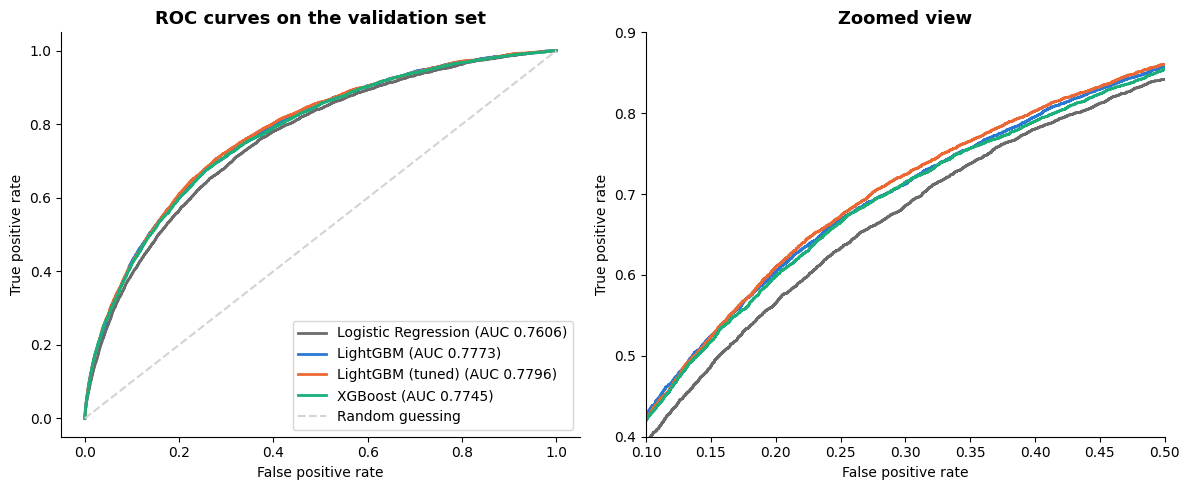

In [17]:
models = {
    'Logistic Regression': (log_reg, X_val_scaled, '#6b6b6b'),
    'LightGBM': (lgbm, X_val_lgb, '#2a78d6'),
    'LightGBM (tuned)': (best_lgbm, X_val_lgb, '#eb6834'),
    'XGBoost': (xgb, X_val_lgb, '#1baf7a'),
}

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(12, 5))

for name, (model, X, color) in models.items():
    proba = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    label = f'{name} (AUC {roc_auc_score(y_val, proba):.4f})'
    for ax in (ax_full, ax_zoom):
        ax.plot(fpr, tpr, color=color, linewidth=2, label=label)

ax_full.plot([0, 1], [0, 1], color='lightgray', linestyle='--', linewidth=1.5, label='Random guessing')

ax_full.set_title('ROC curves on the validation set')
ax_full.legend(loc='lower right')

ax_zoom.set_xlim(0.1, 0.5)
ax_zoom.set_ylim(0.4, 0.9)
ax_zoom.set_title('Zoomed view')

for ax in (ax_full, ax_zoom):
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')

plt.tight_layout()
plt.show()

Confirmed: the zoomed view makes the differences visible. All three gradient boosting models lie clearly above the Logistic Regression baseline across the whole range shown: at the same share of wrongly flagged good applicants, they catch a noticeably larger share of the real defaults.

Among the three boosting models, the differences are small: the tuned LightGBM is marginally ahead, followed by the first LightGBM and XGBoost, and the curves overlap in many places. This matches their AUC values (0.7796, 0.7773 and 0.7745) and confirms our earlier conclusion that the boosting models perform practically the same.

We use the tuned LightGBM as our final model for the next steps.

## Precision-Recall Curves

With only 8% defaults, the ROC curve can look more favorable than the model's practical usefulness, because the false positive rate is measured relative to the large group of good applicants. The precision-recall curve focuses on the rare class instead: for every threshold, it plots the share of flagged applicants that are real defaults (precision, y-axis) against the share of all real defaults that were found (recall, x-axis). There is a trade-off between the two: flagging more applicants finds more defaults, but a larger share of the flagged applicants are good customers.

The reference is not a diagonal but a horizontal line at the default rate of 8.07%: that is the precision we would get by flagging applicants at random. The area under the curve is called average precision (AP).

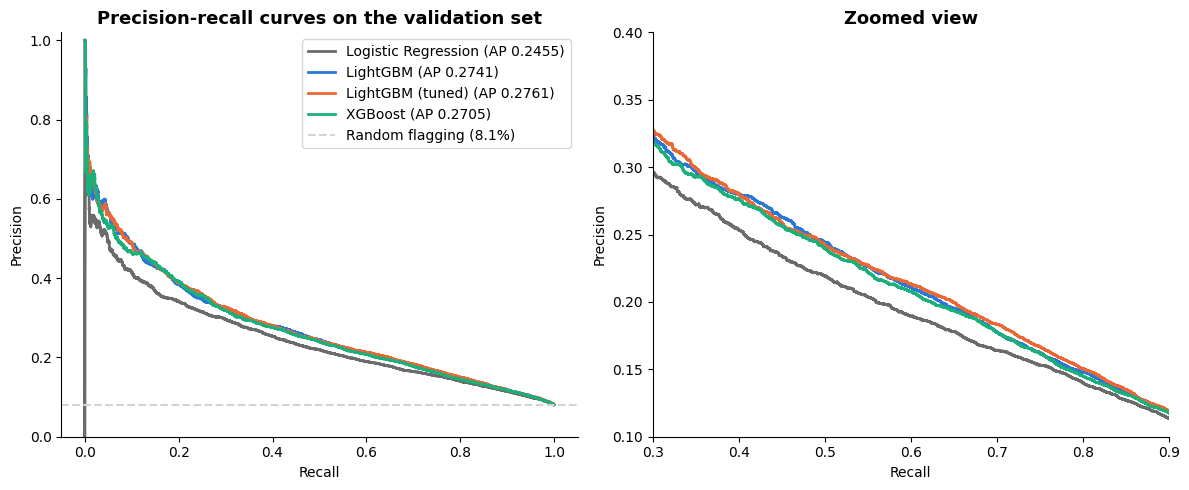

In [18]:
fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(12, 5))

for name, (model, X, color) in models.items():
    proba = model.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y_val, proba)
    label = f'{name} (AP {average_precision_score(y_val, proba):.4f})'
    for ax in (ax_full, ax_zoom):
        ax.plot(recall, precision, color=color, linewidth=2, label=label)

default_rate = y_val.mean()
ax_full.axhline(default_rate, color='lightgray', linestyle='--', linewidth=1.5,
                label=f'Random flagging ({default_rate:.1%})')

ax_full.set_title('Precision-recall curves on the validation set')
ax_full.set_ylim(0, 1.02)
ax_full.legend(loc='upper right')

ax_zoom.set_xlim(0.3, 0.9)
ax_zoom.set_ylim(0.1, 0.4)
ax_zoom.set_title('Zoomed view')

for ax in (ax_full, ax_zoom):
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

plt.tight_layout()
plt.show()

In [19]:
precision, recall, _ = precision_recall_curve(y_val, best_lgbm.predict_proba(X_val_lgb)[:, 1])

for target_recall in [0.3, 0.6, 0.9]:
    idx = np.where(recall >= target_recall)[0][-1]
    print(f'Recall {target_recall}: precision = {precision[idx]:.3f}')

Recall 0.3: precision = 0.327
Recall 0.6: precision = 0.213
Recall 0.9: precision = 0.118


Confirmed: the precision-recall curves tell the same story as the ROC curves, but make the practical trade-off more tangible. All models stay clearly above the 8.1% of random flagging, and all curves fall as recall rises: the more of the real defaults we want to find, the larger the share of good applicants among the flagged ones. For our best model, the tuned LightGBM, precision is 0.327 at a recall of 0.3, 0.213 at a recall of 0.6 and 0.118 at a recall of 0.9. In other words: if we want to catch 60% of all defaults, about one in five flagged applicants is a real default, which is still 2.6 times the base rate of 8.1%. At a recall of 0.3 the precision is about four times the base rate; at a recall of 0.9 it is only about 1.5 times.

The average precision (AP) ranks the models in the same order as the AUC-ROC: tuned LightGBM (0.2761), LightGBM (0.2741), XGBoost (0.2705) and the Logistic Regression baseline (0.2455). The three boosting models are again close together, while the baseline is clearly behind, most visibly in the region of low to medium recall. At the very left of the plot (recall close to 0), the curves are jagged and spike up to a precision of 1.0: there, only a handful of applicants with the highest scores are flagged, so single cases change the value strongly. This part is not reliable and does not matter for practical decisions.

## From Scores to Decisions: Confusion Matrix and Thresholds

The ROC and precision-recall curves show how well the model ranks applicants across all possible thresholds, but a bank has to make a decision for each one: approve or reject. This requires a threshold: applicants whose predicted default probability lies above it are flagged as risky. The confusion matrix shows what this decision looks like in practice, by comparing the flagged applicants with the real outcomes:

* True negatives: good applicants correctly approved.
* False positives: good applicants wrongly flagged as risky (lost business).
* False negatives: real defaults that were missed (lost money).
* True positives: real defaults correctly flagged.

We start with the standard threshold of 0.5 for our final model, the tuned LightGBM. Because we trained with class weighting, the predicted probabilities are pushed upwards: the model was told that a default is about 11 times as important as a repayment. We therefore expect that a threshold of 0.5 flags far more applicants than there are actual defaults.

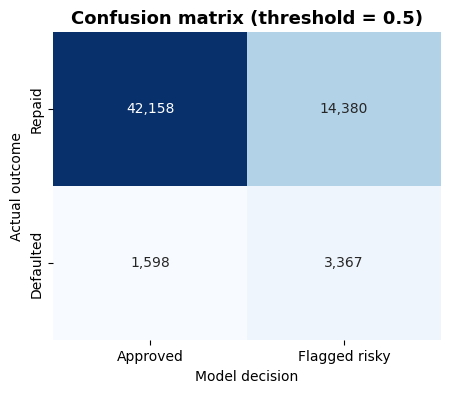

Flagged as risky: 28.9% of all applicants
Recall (defaults found): 67.8%
Precision (flagged that defaulted): 19.0%


In [20]:
threshold = 0.5
proba_val = best_lgbm.predict_proba(X_val_lgb)[:, 1]
y_pred = (proba_val >= threshold).astype(int)

cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Approved', 'Flagged risky'],
            yticklabels=['Repaid', 'Defaulted'])
ax.set_xlabel('Model decision')
ax.set_ylabel('Actual outcome')
ax.set_title(f'Confusion matrix (threshold = {threshold})')
plt.show()

print('Flagged as risky:', f'{(tp + fp) / len(y_val):.1%}', 'of all applicants')
print('Recall (defaults found):', f'{tp / (tp + fn):.1%}')
print('Precision (flagged that defaulted):', f'{tp / (tp + fp):.1%}')

Confirmed: at the standard threshold of 0.5, the model flags 17,747 of the 61,503 validation applicants (28.9%) as risky, although only 4,965 of them (8.1%) actually defaulted. This is the effect of class weighting we expected: the predicted probabilities are pushed upwards, so a threshold of 0.5 is far too low to mean "more likely a default than not".

In business terms, this operating point looks as follows:

- **3,367 defaults found (recall 67.8%)** and **1,598 defaults missed** (lost money).
- **14,380 good applicants wrongly flagged** (false positive rate 25.4%, lost business). Among all flagged applicants, only 19.0% actually defaulted (precision), which is about 2.4 times the base rate of 8.1%.
- **42,158 good applicants correctly approved.**

This point lies on the ROC curve we saw earlier: a true positive rate of 0.68 at a false positive rate of 0.25. The threshold is the lever that moves us along the ROC and precision-recall curves. A lower threshold flags more applicants: we find more defaults (higher recall), but also wrongly reject more good applicants (lower precision). A higher threshold does the opposite. There is no single correct value, since the best choice depends on how costly a missed default is compared to a rejected good applicant.

To make this trade-off tangible, we evaluate the final model at several thresholds and compare the share of flagged applicants, the number of missed defaults and wrongly rejected good applicants, as well as recall and precision. Because of the class weighting, the probabilities are inflated, so we look at thresholds between 0.3 and 0.8.

In [21]:
y_true = (y_val.values == 1)

rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    flagged = proba_val >= t
    tp = (flagged & y_true).sum()
    fp = (flagged & ~y_true).sum()
    fn = (~flagged & y_true).sum()
    rows.append({
        'threshold': t,
        'flagged_share': flagged.mean(),
        'defaults_found': tp,
        'defaults_missed': fn,
        'good_rejected': fp,
        'recall': tp / (tp + fn),
        'precision': tp / (tp + fp),
    })

threshold_table = pd.DataFrame(rows).set_index('threshold')

# Compared to the previous (lower) threshold: good applicants spared per additionally missed default
threshold_table['good_spared_per_default_lost'] = (
    threshold_table['good_rejected'].diff() / threshold_table['defaults_found'].diff()
)

threshold_table.round(3)

,flagged_share,defaults_found,defaults_missed,good_rejected,recall,precision,good_spared_per_default_lost
threshold,,,,,,,
0.3,0.567,4359,606,30495,0.878,0.125,NaN
0.4,0.414,3921,1044,21552,0.790,0.154,20.418
0.5,0.289,3367,1598,14380,0.678,0.190,12.946
0.6,0.187,2658,2307,8814,0.535,0.232,7.850
0.7,0.101,1820,3145,4420,0.367,0.292,5.243
0.8,0.038,925,4040,1391,0.186,0.399,3.384


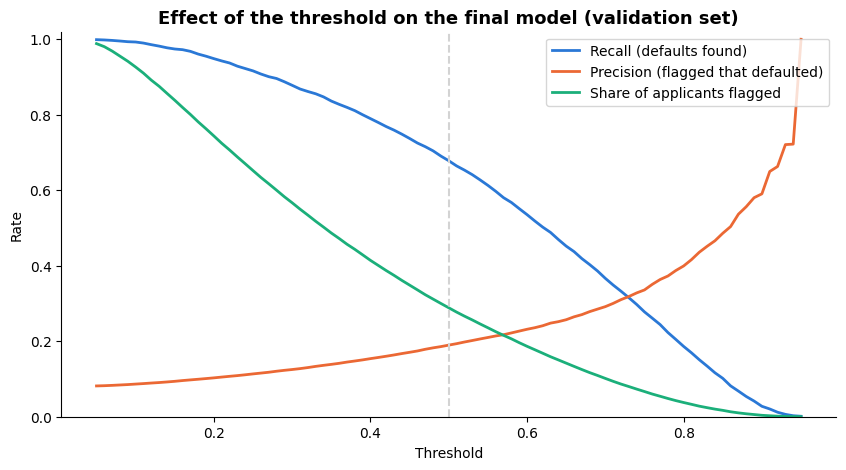

In [22]:
thresholds = np.linspace(0.05, 0.95, 91)

recall_curve, precision_curve, flagged_curve = [], [], []
for t in thresholds:
    flagged = proba_val >= t
    tp = (flagged & y_true).sum()
    recall_curve.append(tp / y_true.sum())
    precision_curve.append(tp / flagged.sum() if flagged.sum() > 0 else np.nan)
    flagged_curve.append(flagged.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recall_curve, color='#2a78d6', linewidth=2, label='Recall (defaults found)')
ax.plot(thresholds, precision_curve, color='#eb6834', linewidth=2, label='Precision (flagged that defaulted)')
ax.plot(thresholds, flagged_curve, color='#1baf7a', linewidth=2, label='Share of applicants flagged')
ax.axvline(0.5, color='lightgray', linestyle='--', linewidth=1.5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.02)
ax.set_title('Effect of the threshold on the final model (validation set)')
ax.legend(loc='upper right')
plt.show()

Confirmed: the table and the chart show the trade-off clearly. In the chart, recall (blue) and the share of flagged applicants (green) fall steadily as the threshold rises, while precision (orange) increases only slowly at first and rises steeply above roughly 0.8. At the far right, precision jumps to 1.0, but this rests on very few flagged applicants and is not reliable. The dashed line marks the standard threshold of 0.5 from the confusion matrix, where recall is 0.68 and precision 0.19.

The table gives the exact values. At a threshold of 0.3, the model flags 56.7% of all applicants and finds 87.8% of the defaults, but only 12.5% of the flagged applicants are real defaults and 30,495 good applicants are rejected. At 0.8, only 3.8% of applicants are flagged and precision rises to 39.9%, but 81.4% of the defaults are missed (4,040 of 4,965). Each row adds up correctly: defaults found plus defaults missed always equal the 4,965 real defaults in the validation set.

The choice of threshold depends on costs, which the last column of the table expresses: compared to the previous row, it shows how many good applicants are spared from rejection per additionally missed default. Moving from 0.5 to 0.6, for example, means finding 709 fewer defaults (3,367 to 2,658) but rejecting 5,566 fewer good applicants (14,380 to 8,814), i.e. about 7.9 good applicants spared per missed default. For the other steps, this ratio is about 20.4 (0.3 to 0.4), 12.9 (0.4 to 0.5), 5.2 (0.6 to 0.7) and 3.4 (0.7 to 0.8). Raising the threshold pays off as long as this ratio is larger than the cost of a missed default relative to the cost of a wrongly rejected good applicant.

The real cost ratio depends on the product and the individual loan: a missed default costs a large part of the loan amount (depending on collateral), while a rejected good applicant only costs the lost interest margin. The dataset contains no cost information, so we illustrate the logic with two assumed ratios. If a missed default were 5 times as costly as a rejected good applicant, we would go up to a threshold of 0.7 (the ratios 20.4, 12.9, 7.9 and 5.2 are all above 5, while the next step, 3.4, is below). If it were 10 times as costly, we would go up to 0.5 (20.4 and 12.9 are above 10, but the next step, 7.9, is below). A bank would set the threshold based on its own loss and margin figures. What the analysis shows is how large the consequences of this choice are: between 0.3 and 0.8, the share of flagged applicants ranges from 57% to 4%.

## Which Features Drive the Predictions?

For a credit decision, it is not enough that a model predicts well: we also want to know what it relies on. We look at the feature importance of the final model, the tuned LightGBM. LightGBM offers two common measures: the number of times a feature is used for a split ("split") and the total improvement in the loss that these splits bring ("gain"). We use gain, since it reflects how much a feature actually contributes to the predictions, whereas a feature can be used in many splits with only a small effect.

Two caveats apply when reading the result. First, importance shows how much the model uses a feature, not that the feature causes default. Second, when several features are strongly correlated (as with the building features or the related external scores), the importance can be spread between them, so an individual value should not be over-interpreted. We look at the top 15 features to get an overall picture.

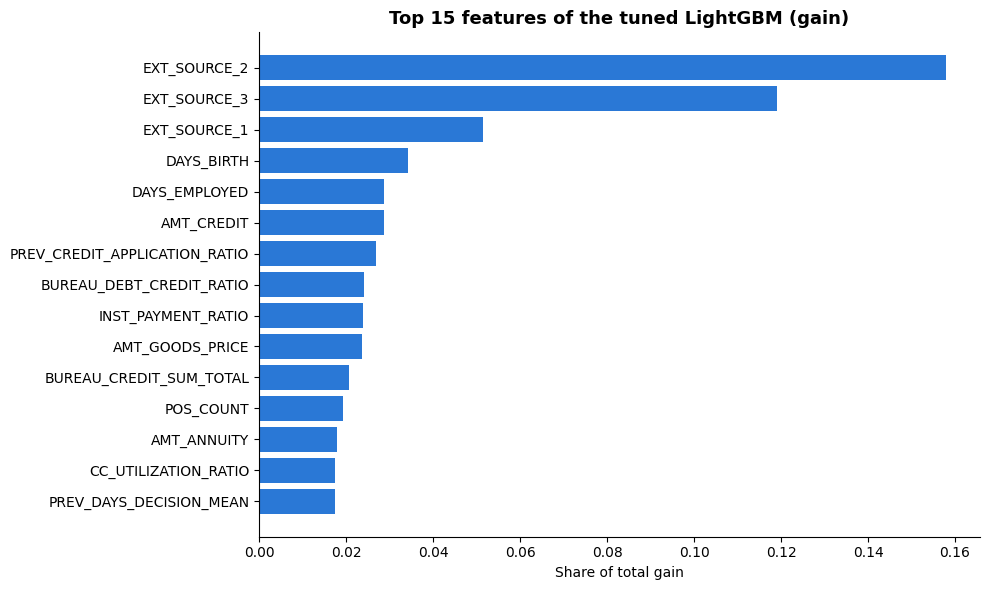

EXT_SOURCE_2                     0.1579
EXT_SOURCE_3                     0.1192
EXT_SOURCE_1                     0.0514
DAYS_BIRTH                       0.0341
DAYS_EMPLOYED                    0.0287
AMT_CREDIT                       0.0287
PREV_CREDIT_APPLICATION_RATIO    0.0270
BUREAU_DEBT_CREDIT_RATIO         0.0240
INST_PAYMENT_RATIO               0.0238
AMT_GOODS_PRICE                  0.0236
BUREAU_CREDIT_SUM_TOTAL          0.0207
POS_COUNT                        0.0193
AMT_ANNUITY                      0.0180
CC_UTILIZATION_RATIO             0.0175
PREV_DAYS_DECISION_MEAN          0.0174
dtype: float64
Top 15 together: 0.611


In [23]:
importance = pd.Series(
    best_lgbm.booster_.feature_importance(importance_type='gain'),
    index=X_train_lgb.columns
)
importance_share = (importance / importance.sum()).sort_values(ascending=False)
top15 = importance_share.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color='#2a78d6')
ax.set_xlabel('Share of total gain')
ax.set_title('Top 15 features of the tuned LightGBM (gain)')
plt.tight_layout()
plt.show()

print(top15.round(4))
print('Top 15 together:', round(top15.sum(), 3))

Confirmed: the model relies most heavily on the three external scores. `EXT_SOURCE_2` (15.8% of the total gain), `EXT_SOURCE_3` (11.9%) and `EXT_SOURCE_1` (5.1%) together account for about 33% of the gain, which matches what we found in the EDA, where these were the strongest predictors. The top 15 features together make up 61.1% of the total gain; the remaining share is spread over the other features.

The chart also shows how much the linked tables contribute: seven of the top 15 features come from them. Four of these are the ratio features we engineered ourselves (`PREV_CREDIT_APPLICATION_RATIO`, `BUREAU_DEBT_CREDIT_RATIO`, `INST_PAYMENT_RATIO` and `CC_UTILIZATION_RATIO`, together about 9.2% of the gain); the other three are aggregations (`BUREAU_CREDIT_SUM_TOTAL`, `POS_COUNT` and `PREV_DAYS_DECISION_MEAN`). So the features from notebook 02 are used heavily by the model: the applicant's payment history and existing credits carry a substantial part of its signal. We did not train a model without them, so we cannot say how much AUC they add.

Two remarks on the interpretation. The importance shows what the model uses, not that a feature causes default. And `DAYS_BIRTH` (the applicant's age) is the fourth most important feature: age is a sensitive attribute in credit decisions in many jurisdictions, so a real deployment would need to review whether it may be used at all. Gender (`CODE_GENDER`) does not appear among the top 15; we check the model's behavior across gender groups in the next step.

## Fairness Check: Model Behavior Across Gender Groups

A model can treat groups of applicants differently even if a sensitive attribute is not among its most important features, because other features can be correlated with it. Since credit decisions are a regulated area, we check how our final model, at the standard threshold of 0.5, behaves for the gender groups in the data: how many applicants of each group it flags as risky, how many of the real defaults it finds (recall) and how many of the flagged applicants actually defaulted (precision).

A note on the data: the column `CODE_GENDER` of this dataset only contains the values "M" and "F" (plus four rows in the training data with an unknown value, which we treated as missing in notebook 02; two of them fall into our validation set). The data was collected at a time when other gender categories were typically not recorded, so the check can only compare these two groups and says nothing about other gender identities. Differences between the groups do not automatically indicate unfair treatment: the groups can also differ in their actual default rates, so we look at these as well.

In [24]:
gender = np.where(X_val['CODE_GENDER_F'], 'F', np.where(X_val['CODE_GENDER_M'], 'M', 'Unknown'))
flagged = proba_val >= 0.5

rows = []
for g in ['F', 'M']:
    mask = gender == g
    tp = (flagged & y_true & mask).sum()
    fp = (flagged & ~y_true & mask).sum()
    fn = (~flagged & y_true & mask).sum()
    tn = (~flagged & ~y_true & mask).sum()
    rows.append({
        'group': g,
        'applicants': mask.sum(),
        'default_rate': y_true[mask].mean(),
        'flagged_share': flagged[mask].mean(),
        'recall': tp / (tp + fn),
        'false_positive_rate': fp / (fp + tn),
        'precision': tp / (tp + fp),
    })

fairness_table = pd.DataFrame(rows).set_index('group')

print('Rows with unknown gender (not shown):', (gender == 'Unknown').sum())
fairness_table.round(3)

Rows with unknown gender (not shown): 2


,applicants,default_rate,flagged_share,recall,false_positive_rate,precision
group,,,,,,
F,40561,0.070,0.239,0.618,0.211,0.181
M,20940,0.102,0.384,0.758,0.342,0.200


Confirmed: at the threshold of 0.5, the model treats the two groups differently. Male applicants are flagged much more often (38.4% vs. 23.9%), and the model finds more of their real defaults (recall 75.8% vs. 61.8%). At the same time, good male applicants are wrongly flagged more often: the false positive rate is 34.2% for men and 21.1% for women, a ratio of about 1.6. Precision is similar in both groups (20.0% vs. 18.1%), i.e. a flag is about equally reliable for men and women.

Part of the difference reflects the data: men have a higher actual default rate in the validation set (10.2% vs. 7.0%), so a model that predicts risk well is expected to flag them more often. The flagged shares differ by a factor of about 1.6, the default rates by about 1.5. However, the higher false positive rate means that a good male applicant has a higher chance of being rejected than a good female applicant with the same threshold, which is a form of unequal treatment that would need to be discussed. Different fairness criteria (e.g. equal flagged shares, equal error rates, equal precision) generally cannot all be satisfied at the same time when the groups' default rates differ, so choosing between them is a decision that goes beyond the data.

Some limits of this check: gender was not among the most important features of the model, so the differences most likely arise from other features that correlate with gender and from real differences in the groups, but we did not test this. The check compares only the two groups recorded in the data and is based on a single threshold and a single validation set. It shows where a review would have to look; it does not prove or exclude unfair treatment.

## Conclusion

**Results.** The best model is the tuned LightGBM with a validation AUC-ROC of 0.7796, compared to 0.7606 for the Logistic Regression baseline. The three gradient boosting models (LightGBM 0.7773, tuned LightGBM 0.7796, XGBoost 0.7745) perform practically the same, and the hyperparameter search brought no meaningful gain over the default settings. All models are clearly above random guessing, and the precision-recall curves confirm the ranking. For context: the top solutions of the original Kaggle competition reached an AUC of about 0.80 on the hidden test set, using large ensembles and extensive feature engineering. Our single models are not directly comparable to those scores, but they show that a single, comparatively simple model gets reasonably close.

**From scores to decisions.** At the standard threshold of 0.5, the final model flags 28.9% of the applicants, finds 67.8% of the defaults and 19.0% of the flagged applicants actually defaulted. The threshold is a business decision: it depends on how costly a missed default is compared to a rejected good applicant, which the dataset does not tell us. The table and chart above show how strongly the choice matters (between 0.3 and 0.8, the share of flagged applicants ranges from 57% to 4%).

**What drives the model.** The three external scores (`EXT_SOURCE_1/2/3`) carry about a third of the model's gain. Seven of the top 15 features come from the linked tables, four of them from the ratio features engineered in notebook 02, so these features are used heavily by the model (we did not measure how much AUC they add).

**Fairness.** Male applicants are flagged more often than female applicants (38.4% vs. 23.9%), partly because their actual default rate is higher (10.2% vs. 7.0%), but good male applicants are also wrongly flagged more often (false positive rate 34.2% vs. 21.1%). The check covers only the two groups recorded in the data.

**Limitations and possible next steps.**

- Preprocessing statistics (imputation medians, income cap, one-hot categories) were computed on the full training data before the split, which lets a small amount of validation information into preprocessing (see the Limitations section above).
- Two of the best hyperparameters lay at the edge of our search range, so a wider search might find slightly better settings; the gains are likely small.
- All results come from one validation set. The threshold analysis uses assumed cost ratios, and the causes of the different default rates between gender groups were not investigated.
- The table `bureau_balance` was left out; features from it are a possible source of further improvement.